<a href="https://colab.research.google.com/github/DahliaHye/-taskflow/blob/main/MDER_MA_%EA%B8%B0%EB%B0%98_%EB%A9%80%ED%8B%B0%EB%AA%A8%EB%8B%AC_%EA%B0%90%EC%A0%95_%EC%9D%B8%EC%8B%9D_(%EC%82%AC%EC%A0%84%ED%95%99%EC%8A%B5_%EB%AA%A8%EB%8D%B8_%ED%99%9C%EC%9A%A9).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import zipfile
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from google.colab import drive

drive.mount('/content/drive')

ZIP_PATH = '/content/drive/MyDrive/20260406/MDER-MA Multimodal Emotion Recognition Dataset for.zip'
EXTRACT_PATH = '/content/raw_data'
FINAL_PATH = '/content/dataset'

if os.path.exists(ZIP_PATH):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
    print("✅ 압축 해제 완료!")
else:
    print("❌ 파일을 찾을 수 없습니다. 경로를 다시 확인해주세요.")

#저장 폴더
os.makedirs(f'{FINAL_PATH}/spectrograms', exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ 압축 해제 완료!


In [2]:
import os

# 1. 압축 해제된 경로의 모든 파일 목록 출력
print("--- 압축 해제된 폴더 내부 확인 ---")
for root, dirs, files in os.walk('/content/raw_data'):
    level = root.replace('/content/raw_data', '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 4 * (level + 1)
    for f in files[:5]: # 파일이 너무 많을 수 있으니 5개만 출력
        print(f"{subindent}{f}")

# 2. CSV 파일만 다시 찾아보기
import glob
csv_files = glob.glob("/content/raw_data/**/*.csv", recursive=True)
print(f"\n찾은 CSV 파일 목록: {csv_files}")

--- 압축 해제된 폴더 내부 확인 ---
raw_data/
    MDER-MA Multimodal Emotion Recognition Dataset for/
        ERD-MA/
            ERD-MA Mel-Spectrograms /
                Neutral/
                    Neutral_male_16_1_19.jpg
                    Neutral_female_17_1_23.jpg
                    Happy_male_17_5_6.jpg
                    Neutral_male_53_2_17.jpg
                    Neutral_female_27_1_8.jpg
                Angry/
                    Angry_male_14_1_20.jpg
                    Angry_male_44_1_9.jpg
                    sad_chunk_11.jpg
                    Angry_female_54_1_2.jpg
                    Angry_male_44_1_49.jpg
                Happy/
                    Happy_female_46_1_1.jpg
                    Happy_male_32_4_4.jpg
                    Happy_female_43_3_7.jpg
                    Happy_female_28_1_3.jpg
                    Happy_female_27_1_6.jpg
                Sad/
                    Sad_male_18_1_8.jpg
                    Sad_male_17_1_19.jpg
                    Sad_male_17

In [3]:
import os
import shutil
import pandas as pd
from tqdm import tqdm

# 1. 경로 설정
# 압축 풀린 경로 (출력 결과 기반)
BASE_RAW = '/content/raw_data/MDER-MA Multimodal Emotion Recognition Dataset for/ERD-MA'
TEXT_FOLDER = os.path.join(BASE_RAW, 'ERD-MA Text')
# 이미 잘 만들어진 'Mel-Spectrograms'를 사용하겠습니다.
IMAGE_FOLDER = os.path.join(BASE_RAW, 'ERD-MA Mel-Spectrograms ')

# 최종 저장 경로
FINAL_PATH = '/content/dataset'
SPECTRO_PATH = os.path.join(FINAL_PATH, 'spectrograms')
os.makedirs(SPECTRO_PATH, exist_ok=True)

# 2. 데이터 수집을 위한 리스트
data_list = []
emotions = ['Happy', 'Sad', 'Neutral', 'Angry']

print("데이터 통합 시작...")

for emotion in emotions:
    # 텍스트 폴더 안의 해당 감정 폴더로 이동
    current_text_dir = os.path.join(TEXT_FOLDER, emotion)

    if not os.path.exists(current_text_dir):
        continue

    # 해당 감정 폴더 안의 모든 .txt 파일 탐색
    for filename in os.listdir(current_text_dir):
        if filename.endswith('.txt'):
            file_id = filename.replace('.txt', '') # 확장자 제거하여 ID 생성

            # 텍스트 내용 읽기
            with open(os.path.join(current_text_dir, filename), 'r', encoding='utf-8') as f:
                text_content = f.read().strip()

            # 대응되는 이미지 찾기 및 복사 (.jpg 또는 .png)
            # 이미지 폴더 경로는 실제 구조에 맞춰 확인 필요
            src_img_path = os.path.join(IMAGE_FOLDER, emotion, file_id + '.jpg')
            dst_img_path = os.path.join(SPECTRO_PATH, file_id + '.png') # 관리 편의상 .png로 통일

            if os.path.exists(src_img_path):
                shutil.copy(src_img_path, dst_img_path)
                # 데이터 리스트에 추가
                data_list.append({
                    'Audio_ID': file_id,
                    'Transcription': text_content,
                    'Emotion': emotion
                })

# 3. 데이터프레임 생성 및 CSV 저장
full_df = pd.DataFrame(data_list)

# 요청하신 형식대로 2개의 CSV로 분리 저장
full_df[['Audio_ID', 'Transcription']].to_csv(f'{FINAL_PATH}/texts.csv', index=False)
full_df[['Audio_ID', 'Emotion']].to_csv(f'{FINAL_PATH}/labels.csv', index=False)

print(f"\n✅ 완료!")
print(f"총 수집된 데이터 개수: {len(full_df)}")
print(f"저장 위치: {FINAL_PATH}")

데이터 통합 시작...

✅ 완료!
총 수집된 데이터 개수: 1282
저장 위치: /content/dataset


In [4]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from transformers import AutoTokenizer

# 1. 사전학습된 토크나이저 불러오기 (모로코 아랍어 대응을 위해 다국어 BERT 사용)
tokenizer = AutoTokenizer.from_pretrained('bert-base-multilingual-cased')

class MultimodalDataset(Dataset):
    def __init__(self, texts_csv, labels_csv, img_dir, transform=None):
        self.texts = pd.read_csv(texts_csv)
        self.labels = pd.read_csv(labels_csv)
        self.img_dir = img_dir
        self.transform = transform

        # 감정 라벨을 숫자로 변환 (Happy:0, Sad:1, Angry:2, Neutral:3)
        self.label_map = {'Happy': 0, 'Sad': 1, 'Angry': 2, 'Neutral': 3}

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        # 1. 텍스트 처리
        text = str(self.texts.iloc[idx]['Transcription'])
        inputs = tokenizer(text, padding='max_length', truncation=True, max_length=128, return_tensors="pt")

        # 2. 이미지 처리
        img_id = self.texts.iloc[idx]['Audio_ID']
        img_path = os.path.join(self.img_dir, f"{img_id}.png")
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        # 3. 라벨 처리
        label_name = self.labels.iloc[idx]['Emotion']
        label = torch.tensor(self.label_map[label_name])

        return {
            'input_ids': inputs['input_ids'].squeeze(0),
            'attention_mask': inputs['attention_mask'].squeeze(0),
            'image': image,
            'label': label
        }

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [5]:
from torchvision import transforms
from sklearn.model_selection import train_test_split

# 1. 성능 향상 전략: 데이터 증강 (Image Augmentation)
#데이터가 적을 때 모델이 외우는 것(Overfitting)을 방지하고 일반화 능력을 키웁니다.
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(), # 좌우 반전
    transforms.RandomRotation(10),      # 살짝 회전
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 2. 데이터 나누기 (학습용 80%, 검증용 20%)
full_dataset = MultimodalDataset(f'{FINAL_PATH}/texts.csv', f'{FINAL_PATH}/labels.csv', SPECTRO_PATH, transform=train_transform)
train_idx, val_idx = train_test_split(range(len(full_dataset)), test_size=0.2, random_state=42)

train_loader = DataLoader(torch.utils.data.Subset(full_dataset, train_idx), batch_size=16, shuffle=True)
val_loader = DataLoader(torch.utils.data.Subset(full_dataset, val_idx), batch_size=16, shuffle=False)

In [6]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# 라벨 데이터 로드
labels_df = pd.read_csv(f'{FINAL_PATH}/labels.csv')
class_names = ['Happy', 'Sad', 'Angry', 'Neutral']

# y_train 데이터 생성 (학습 세트에 포함된 라벨들)
y_train = [labels_df[labels_df['Audio_ID'] == full_dataset.texts.iloc[i]['Audio_ID']]['Emotion'].values[0] for i in train_idx]

# 가중치 계산
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array(class_names),
    y=y_train
)

# PyTorch에서 사용할 수 있도록 텐서로 변환
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print(f"✅ 가중치 계산 성공: {class_weights}")
print(f"현재 사용 중인 장치: {device}")

✅ 가중치 계산 성공: [1.01284585 0.98938224 1.09508547 0.91845878]
현재 사용 중인 장치: cuda


In [9]:
import torch.nn as nn
from torchvision import models
from transformers import AutoModel

class MultimodalEmotionModel(nn.Module):
    def __init__(self, num_classes=4, fusion_type='gated'):
        super(MultimodalEmotionModel, self).__init__()
        self.fusion_type = fusion_type

        # 1. 이미지 엔코더: ResNet18 (사전학습됨)
        # weights=models.ResNet18_Weights.DEFAULT 는 최신 파이토치 방식입니다.
        self.image_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.image_model.fc = nn.Linear(self.image_model.fc.in_features, 256)

        # 2. 텍스트 엔코더: BERT (사전학습됨)
        self.text_model = AutoModel.from_pretrained('bert-base-multilingual-cased')
        self.text_hidden_size = 768
        self.text_projector = nn.Linear(self.text_hidden_size, 256)

        # 3. Fusion 레이어
        if fusion_type == 'concat':
            self.classifier = nn.Sequential(
                nn.Linear(256 + 256, 128),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(128, num_classes)
            )
        elif fusion_type == 'gated':
            # 가중치를 계산하여 어느 쪽 정보를 더 많이 쓸지 결정 (성능 향상 전략)
            self.gate = nn.Sequential(
                nn.Linear(256 + 256, 1),
                nn.Sigmoid()
            )
            self.classifier = nn.Linear(256, num_classes)

    def forward(self, input_ids, attention_mask, image):
        # 이미지 특징 추출
        img_features = self.image_model(image) # [batch, 256]

        # 텍스트 특징 추출
        text_outputs = self.text_model(input_ids=input_ids, attention_mask=attention_mask)
        # BERT의 첫 번째 토큰([CLS])의 출력인 pooler_output 사용
        text_features = self.text_projector(text_outputs.pooler_output) # [batch, 256]

        if self.fusion_type == 'concat':
            combined = torch.cat((img_features, text_features), dim=1)
            return self.classifier(combined)

        elif self.fusion_type == 'gated':
            # Gate 메커니즘: 이미지와 텍스트의 중요도를 동적으로 조절
            gate_val = self.gate(torch.cat((img_features, text_features), dim=1))
            combined = gate_val * img_features + (1 - gate_val) * text_features
            return self.classifier(combined)

In [10]:
# 1. 필수 라이브러리 및 데이터 로더 재설정 (세션 초기화 대응)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# 2. 데이터 나누기 및 로더 생성
full_dataset = MultimodalDataset(f'{FINAL_PATH}/texts.csv', f'{FINAL_PATH}/labels.csv', SPECTRO_PATH, transform=train_transform)
train_idx, val_idx = train_test_split(range(len(full_dataset)), test_size=0.2, random_state=42)

train_loader = DataLoader(torch.utils.data.Subset(full_dataset, train_idx), batch_size=16, shuffle=True)
val_loader = DataLoader(torch.utils.data.Subset(full_dataset, val_idx), batch_size=16, shuffle=False)

# 3. 모델 객체 생성 및 GPU 이동
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MultimodalEmotionModel(num_classes=4, fusion_type='gated').to(device)

# 4. 손실 함수와 최적화 도구 (가중치 적용)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

# 5. 학습 시작!
epochs = 5
print(f"현재 장치: {device} | 학습을 시작합니다.")

for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0


    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        images = batch['image'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask, images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels).item()

    acc = correct / len(train_idx)
    print(f"결과 -> Loss: {total_loss/len(train_loader):.4f}, Accuracy: {acc:.4f}")

print("✅ 모든 학습이 완료되었습니다!")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 191MB/s]


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

결과 -> Loss: 0.3761, Accuracy: 0.8946


Epoch 4/5: 100%|██████████| 65/65 [00:38<00:00,  1.68it/s]


결과 -> Loss: 0.3143, Accuracy: 0.9054


Epoch 5/5: 100%|██████████| 65/65 [00:44<00:00,  1.47it/s]

결과 -> Loss: 0.2550, Accuracy: 0.9327
✅ 모든 학습이 완료되었습니다!


In [12]:
# 1. 기록 할 곳 정의
history = {'train_loss': [], 'train_acc': []}

# 2. 진짜 학습 시작 (기록 포함)
epochs = 5
print(f"현재 장치: {device} | 다시 한번 학습을 시작합니다. (이번에는 기록됩니다!)")

for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        images = batch['image'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask, images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels).item()

    # 에폭 종료 후 기록 저장 (이 부분이 추가되었습니다!)
    avg_loss = total_loss / len(train_loader)
    avg_acc = correct / len(train_idx)

    history['train_loss'].append(avg_loss)
    history['train_acc'].append(avg_acc)

    print(f"결과 -> Loss: {avg_loss:.4f}, Accuracy: {avg_acc:.4f}")

print("✅ 기록이 포함된 모든 학습이 완료되었습니다!")

현재 장치: cuda | 다시 한번 학습을 시작합니다. (이번에는 기록됩니다!)


Epoch 1/5: 100%|██████████| 65/65 [00:39<00:00,  1.63it/s]


결과 -> Loss: 0.2207, Accuracy: 0.9298


Epoch 2/5: 100%|██████████| 65/65 [00:35<00:00,  1.81it/s]


결과 -> Loss: 0.1872, Accuracy: 0.9415


...

결과 -> Loss: 0.1638, Accuracy: 0.9541


Epoch 4/5: 100%|██████████| 65/65 [00:36<00:00,  1.78it/s]


결과 -> Loss: 0.1524, Accuracy: 0.9639


Epoch 5/5: 100%|██████████| 65/65 [00:36<00:00,  1.78it/s]

결과 -> Loss: 0.1298, Accuracy: 0.9678
✅ 기록이 포함된 모든 학습이 완료되었습니다!


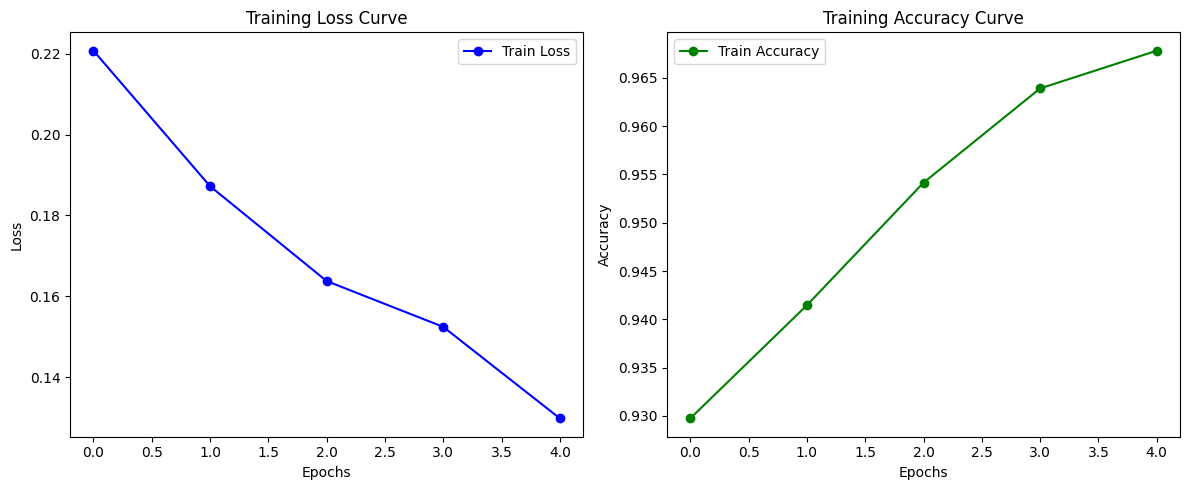

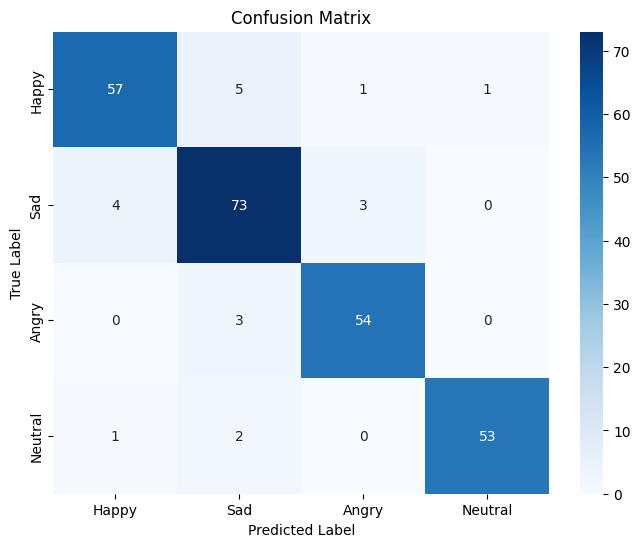


      [ 최종 성능 분석 보고서 ]
              precision    recall  f1-score   support

       Happy       0.92      0.89      0.90        64
         Sad       0.88      0.91      0.90        80
       Angry       0.93      0.95      0.94        57
     Neutral       0.98      0.95      0.96        56

    accuracy                           0.92       257
   macro avg       0.93      0.92      0.93       257
weighted avg       0.92      0.92      0.92       257



In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import pandas as pd

# 1. 학습 곡선 (Loss & Accuracy) 시각화
plt.figure(figsize=(12, 5))

# Loss 그래프: 공부를 얼마나 잘 했는지
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', color='blue', marker='o')
plt.title('Training Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy 그래프: 정답을 얼마나 잘 맞혔는지
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy', color='green', marker='o')
plt.title('Training Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# 2. 검증 데이터를 이용한 혼동 행렬(Confusion Matrix) 계산
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        images = batch['image'].to(device)
        labels = batch['label'].to(device)

        outputs = model(input_ids, attention_mask, images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion Matrix 그리기: 어떤 감정을 헷갈려 하는지 확인
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 3. 최종 성능 지표 리포트 출력
print("\n" + "="*30)
print("      [ 최종 성능 분석 보고서 ]")
print("="*30)
print(classification_report(all_labels, all_preds, target_names=class_names))